In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install ta
#uncomment for "ta" installation

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29482 sha256=084eb7b4ed2a478eef85b6a01e7988d280abd7097a2ecf7ab37440b9ebc936d3
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import ta

#past 5 years data for initial stage(if not enough we will run more longer)

tickers = ["NVDA", "MSFT", "CVX" , "GE", "BRK-B" ]
dfs = {t: yf.Ticker(t).history(period="max") for t in tickers}


def add_indicators(df):
    # Moving Averages
    df["SMA_50"] = ta.trend.sma_indicator(df["Close"], window=50)
    df["SMA_200"] = ta.trend.sma_indicator(df["Close"], window=200)
    df["EMA_50"] = ta.trend.ema_indicator(df["Close"], window=50)
    df["EMA_200"] = ta.trend.ema_indicator(df["Close"], window=200)

    # RSI
    df["RSI"] = ta.momentum.rsi(df["Close"], window=14)

    # MACD
    df["MACD"] = ta.trend.macd(df["Close"])
    df["MACD_Signal"] = ta.trend.macd_signal(df["Close"])
    df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]

    # Bollinger Bands
    df["BB_Upper"] = ta.volatility.bollinger_hband(df["Close"], window=20)
    df["BB_Middle"] = ta.volatility.bollinger_mavg(df["Close"], window=20)
    df["BB_Lower"] = ta.volatility.bollinger_lband(df["Close"], window=20)

    # ATR
    df["ATR"] = ta.volatility.average_true_range(df["High"], df["Low"], df["Close"], window=14)

    # ADX
    df["ADX"] = ta.trend.adx(df["High"], df["Low"], df["Close"], window=14)

    return df

for t in tickers:
    dfs[t] = add_indicators(dfs[t])

for t in tickers:
    print(f"\n--- {t} ---")
    print(dfs[t].tail())


--- NVDA ---
                                 Open        High         Low       Close  \
Date                                                                        
2026-07-15 00:00:00-04:00  211.960007  213.809998  206.039993  212.500000   
2026-07-16 00:00:00-04:00  210.169998  211.080002  205.850006  207.399994   
2026-07-17 00:00:00-04:00  202.639999  206.649994  197.970001  202.809998   
2026-07-20 00:00:00-04:00  205.869995  207.740005  202.279999  203.279999   
2026-07-21 00:00:00-04:00  207.539993  208.649994  207.494995  207.869995   

                              Volume  Dividends  Stock Splits      SMA_50  \
Date                                                                        
2026-07-15 00:00:00-04:00  124797200        0.0           0.0  209.499081   
2026-07-16 00:00:00-04:00  122986100        0.0           0.0  209.682102   
2026-07-17 00:00:00-04:00  144281900        0.0           0.0  209.812877   
2026-07-20 00:00:00-04:00   88489800        0.0           0.0

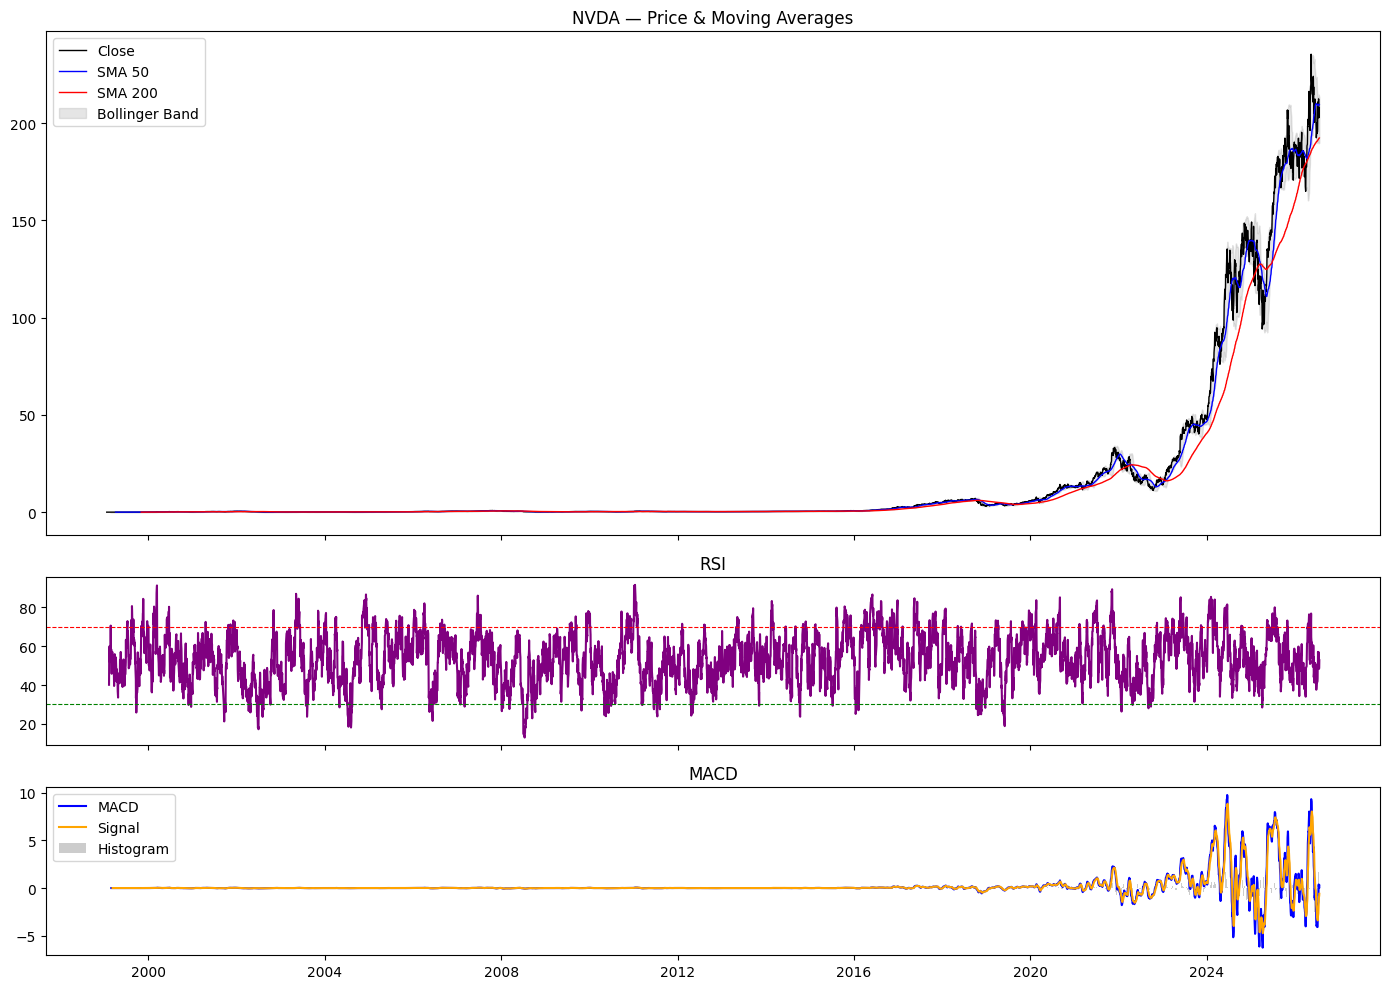

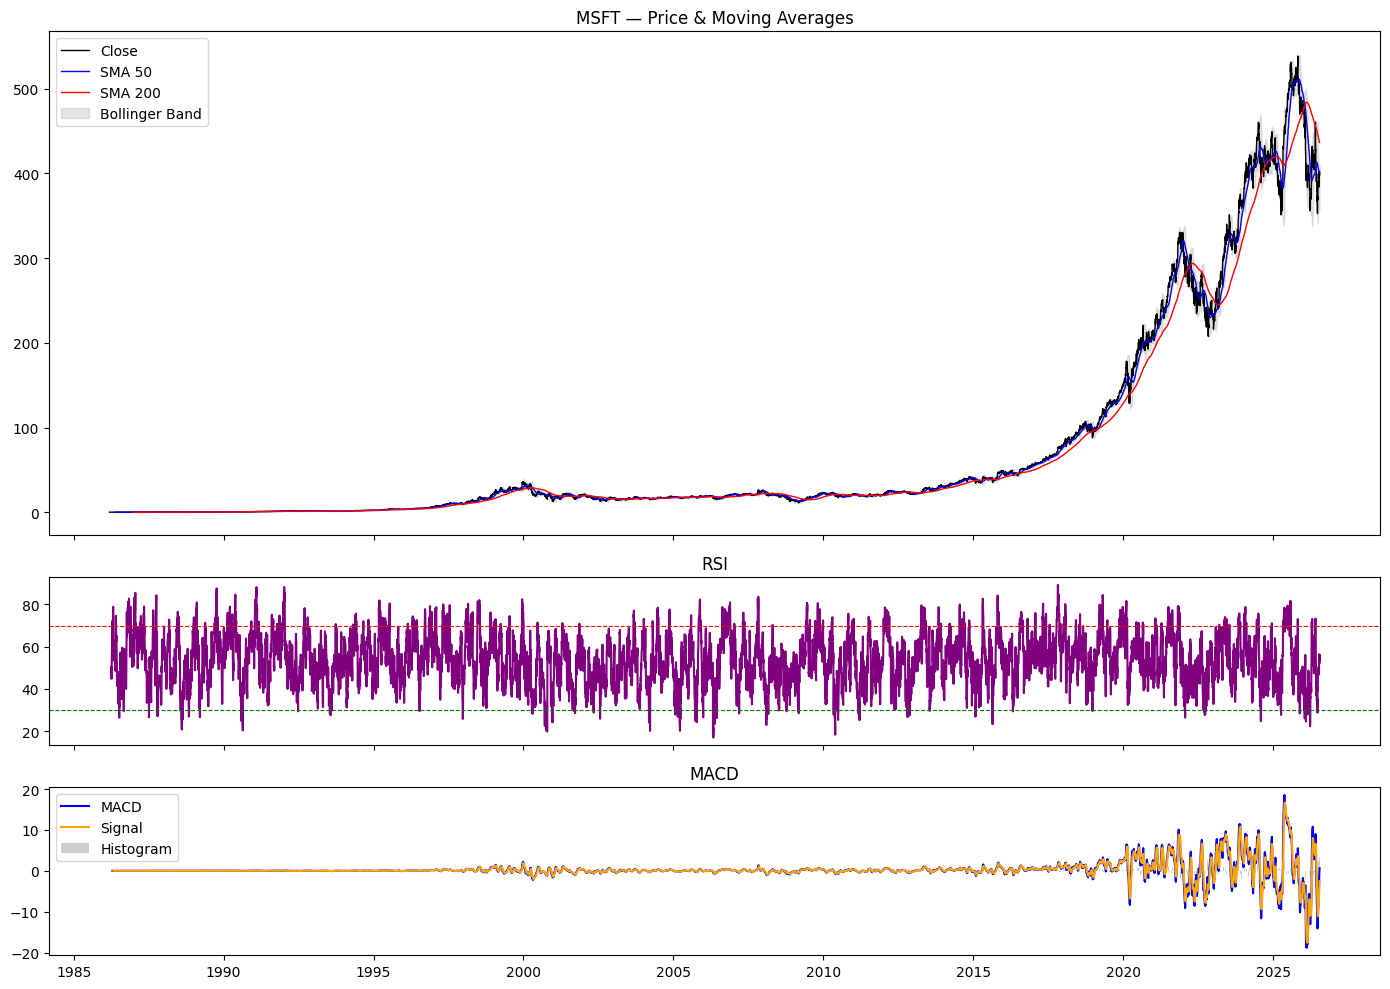

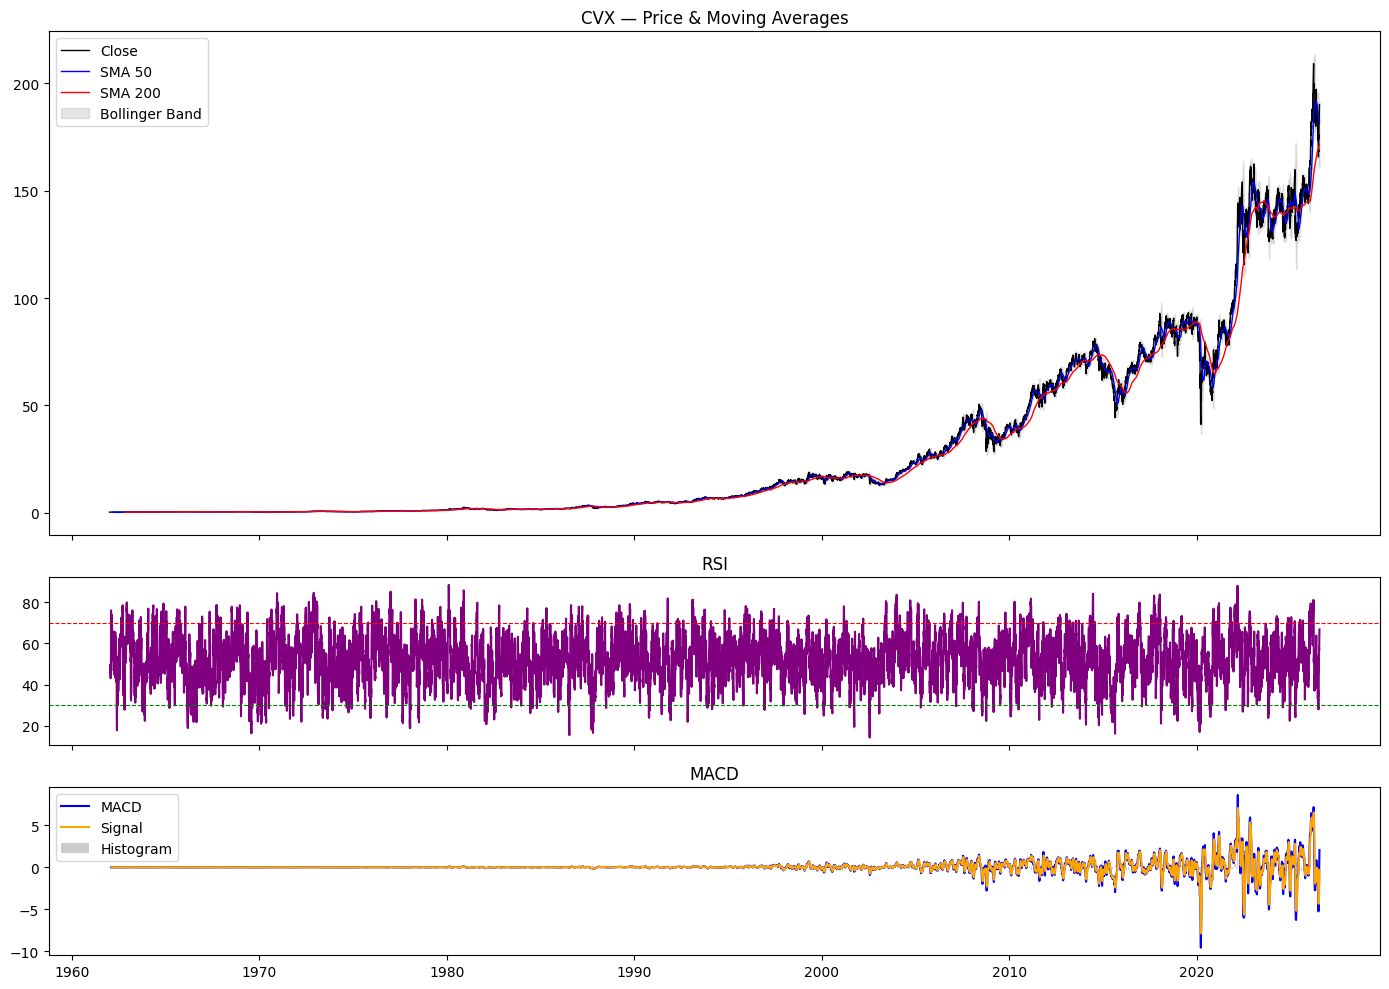

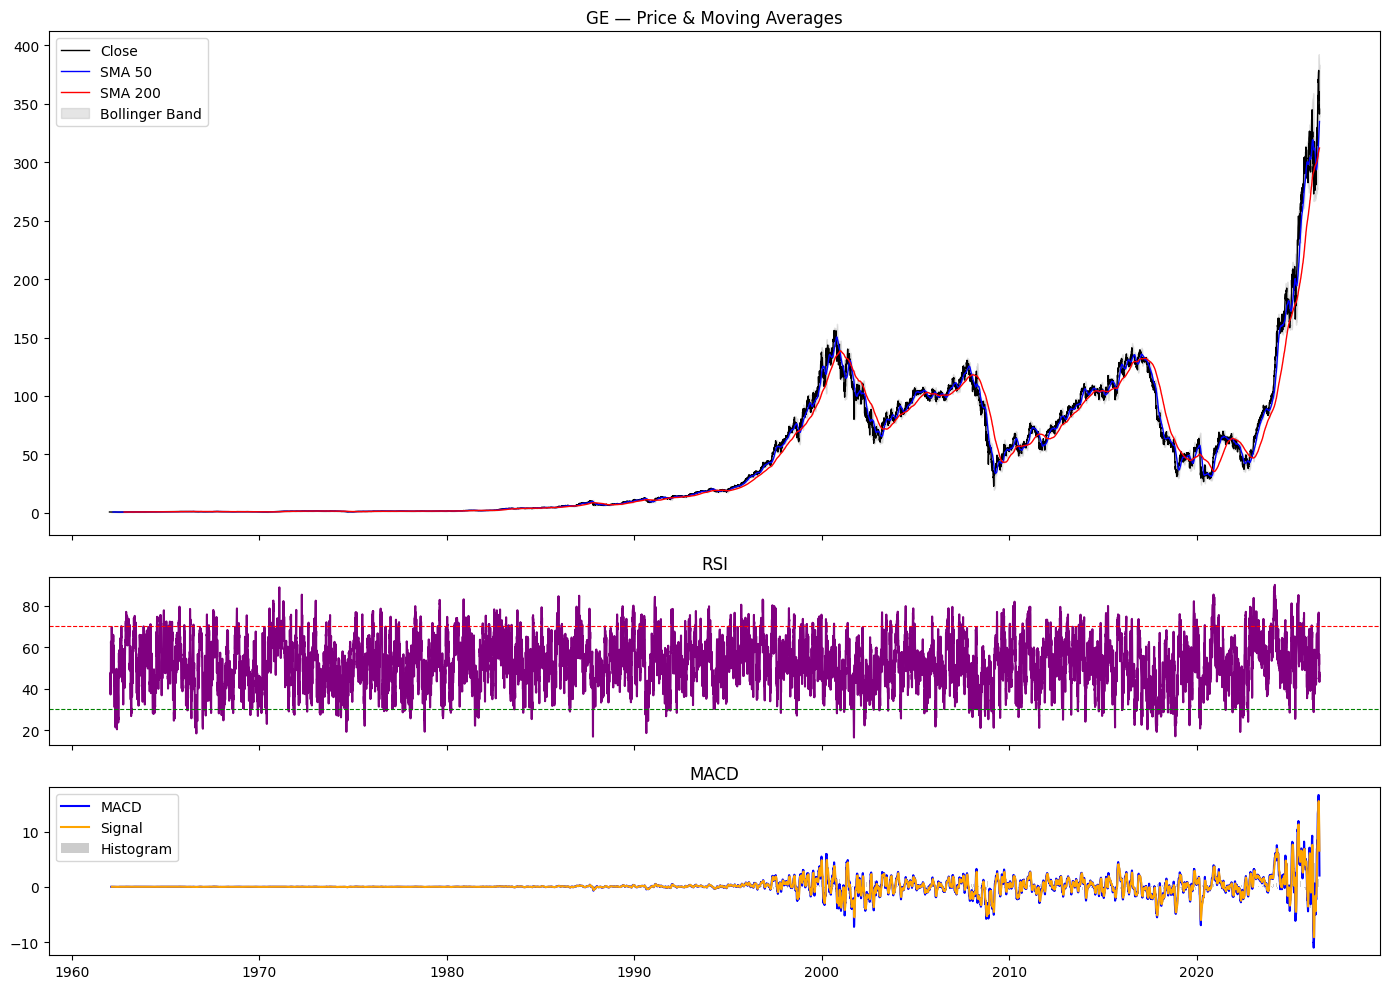

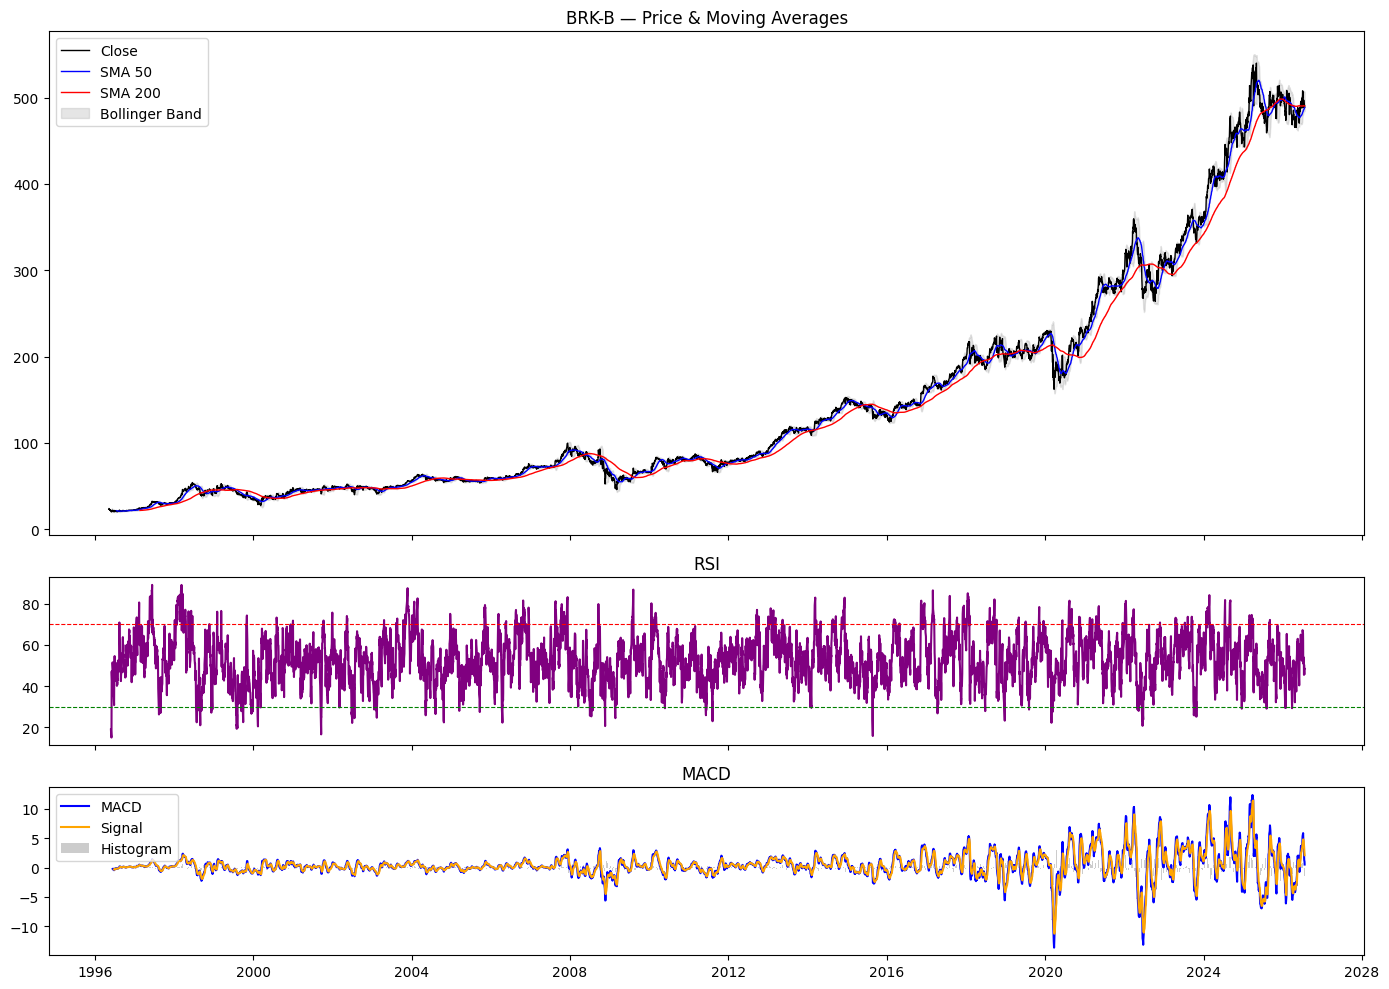

In [4]:
import matplotlib.pyplot as plt

def plot_stock(df, ticker):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1, 1]})

    # Price + Moving Averages + Bollinger Bands
    axes[0].plot(df.index, df["Close"], label="Close", color="black", linewidth=1)
    axes[0].plot(df.index, df["SMA_50"], label="SMA 50", color="blue", linewidth=1)
    axes[0].plot(df.index, df["SMA_200"], label="SMA 200", color="red", linewidth=1)
    axes[0].fill_between(df.index, df["BB_Upper"], df["BB_Lower"], color="grey", alpha=0.2, label="Bollinger Band")
    axes[0].set_title(f"{ticker} — Price & Moving Averages")
    axes[0].legend(loc="upper left")

    # RSI
    axes[1].plot(df.index, df["RSI"], color="purple")
    axes[1].axhline(70, color="red", linestyle="--", linewidth=0.8)
    axes[1].axhline(30, color="green", linestyle="--", linewidth=0.8)
    axes[1].set_title("RSI")

    # MACD
    axes[2].plot(df.index, df["MACD"], label="MACD", color="blue")
    axes[2].plot(df.index, df["MACD_Signal"], label="Signal", color="orange")
    axes[2].bar(df.index, df["MACD_Hist"], label="Histogram", color="grey", alpha=0.4)
    axes[2].set_title("MACD")
    axes[2].legend(loc="upper left")

    plt.tight_layout()
    plt.show()

# Plot one ticker
# plot_stock(dfs["NVDA"], "NVDA")

for t in tickers:
    plot_stock(dfs[t], t)

In [5]:
import os
import pandas as pd

os.makedirs("stock_data_output", exist_ok=True)

combined = pd.concat(dfs, names=["Ticker", "Date"])
combined.to_csv("stock_data_output/all_tickers_combined.csv")

# Data Summary
# ------------
# Source: yfinance (Ticker.history, period="max")
# Coverage: 1996–2026 (~30 years), varies slightly by ticker based on IPO/listing date
# Tickers: NVDA, MSFT, CVX, GE, BRK-B
# Frequency: Daily OHLCV + technical indicators (SMA, EMA, RSI, MACD, Bollinger Bands, ATR, ADX)